In [5]:
%matplotlib inline
from IPython.display import display
import matplotlib.pyplot as plt
import pathlib

from validphys.pdfgrids import xgrid

from ntkpdf.api import API
from ntkpdf.plotting.pdfplots_providers import DEFAULT_FLAVOURS, DEFAULT_YLABELS
from ntkpdf.plotting.pdfplots_utils import plot_grids
from ntkpdf.utils import XGRID, EVOL_LIST

In [2]:
SAVEPATH = pathlib.Path.cwd() / "figs" / "pdf_plots"
SAVEPATH.mkdir(parents=True, exist_ok=True)

In [12]:
FITS = [
    "260611-ac-03-ntk-sgd", # gamma = 0.001
    "260611-ac-01-ntk-sgd", # gamma = 1
    "260622-ac-01-ntk-sgd", # gamma = 2
    "260611-ac-02-ntk-sgd", # gamma = 3
    "260622-ac-02-ntk-sgd", # gamma = 4
    "260622-ac-03-ntk-sgd", # gamma = 5
    "260622-ac-03-ntk-sgd-long", # gamma = 5
]
FITS_DICT = {"gamma_001",
             "gamma_1",
             "gamma_2",
             "gamma_3",
             "gamma_4",
             "gamma_5",
             "gamma_5_long",
}
fakepdf = API.fit(fit=FITS[0]).as_input()['closuretest']['fakepdf']

In [13]:
fakepdf_grid = API.xplotting_grids(pdfs=[fakepdf], Q=1.65, basis="evolution", flavours = EVOL_LIST, xgrid=XGRID)[0]
grids = []
grids.append(API.pdf_grid_at_epoch(fit=FITS[1], epoch=17500))
grids.append(API.pdf_grid_at_epoch(fit=FITS[3], epoch=17500))
grids.append(API.pdf_grid_at_epoch(fit=FITS[5], epoch=17500))
grids.append(fakepdf_grid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


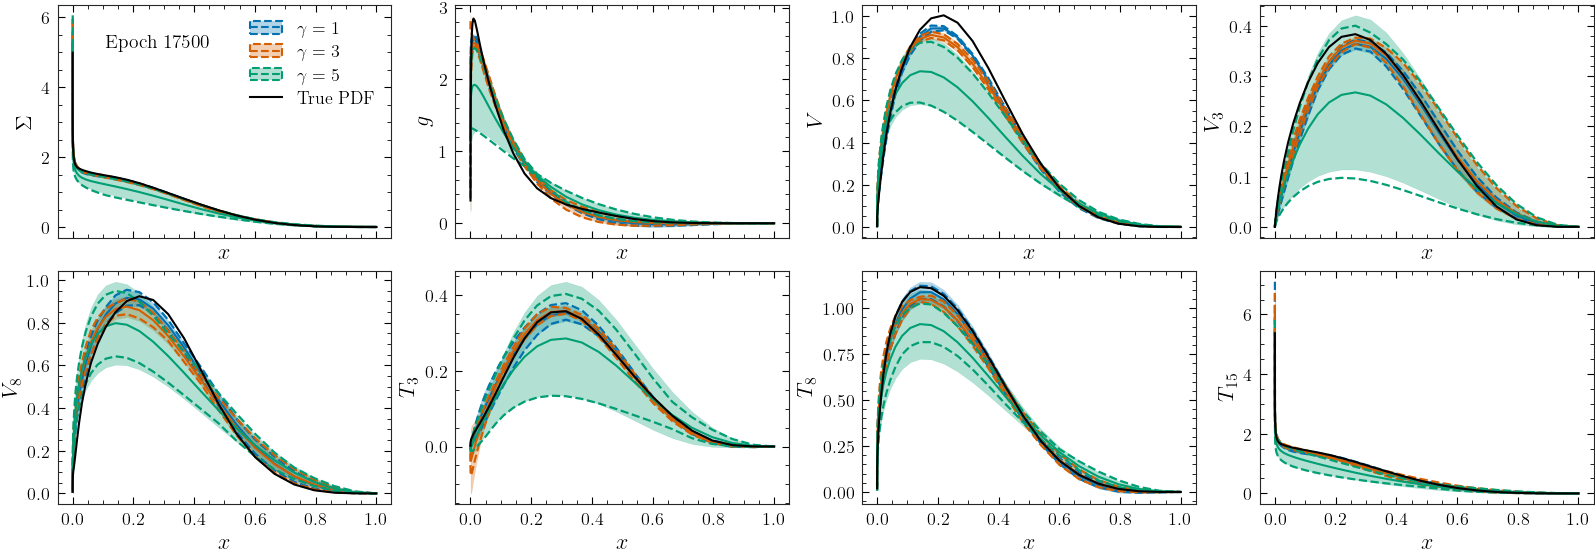

In [15]:
ncols = 4
nrows = -(-len(DEFAULT_FLAVOURS) // ncols)   # ceil
labels = [
  r"$\rm \gamma = 1$", 
  r"$\rm \gamma = 3$", 
  r"$\rm \gamma = 5$", 
]

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows),
                            sharex=True, constrained_layout=True)

_ = list(plot_grids(
  grids, 
  flavours=DEFAULT_FLAVOURS, 
  ylabels=DEFAULT_YLABELS,
  labels=labels + [r"True PDF"],
  # normalise_to=1,
  xscale="linear",
  plot_args=[
      {}, {}, {},
      {"linestyle": "solid", "color":"black", "no_bands": True },
  ],
  axes=axes.flatten()
))

for i, ax in enumerate(axes.flatten()):
    lg = ax.get_legend()
    if lg is not None and i != 0:
        lg.remove()
    if i == 0:
        ax.text(0.3, 0.8, "Epoch 17500", ha="center", va="bottom", transform=ax.transAxes)

plt.savefig(SAVEPATH / "pdfs_gamma.pdf")


In [16]:
grids = []
grids.append(API.pdf_grid_at_epoch(fit="260622-ac-03-ntk-sgd-long", epoch=50000))
grids.append(fakepdf_grid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


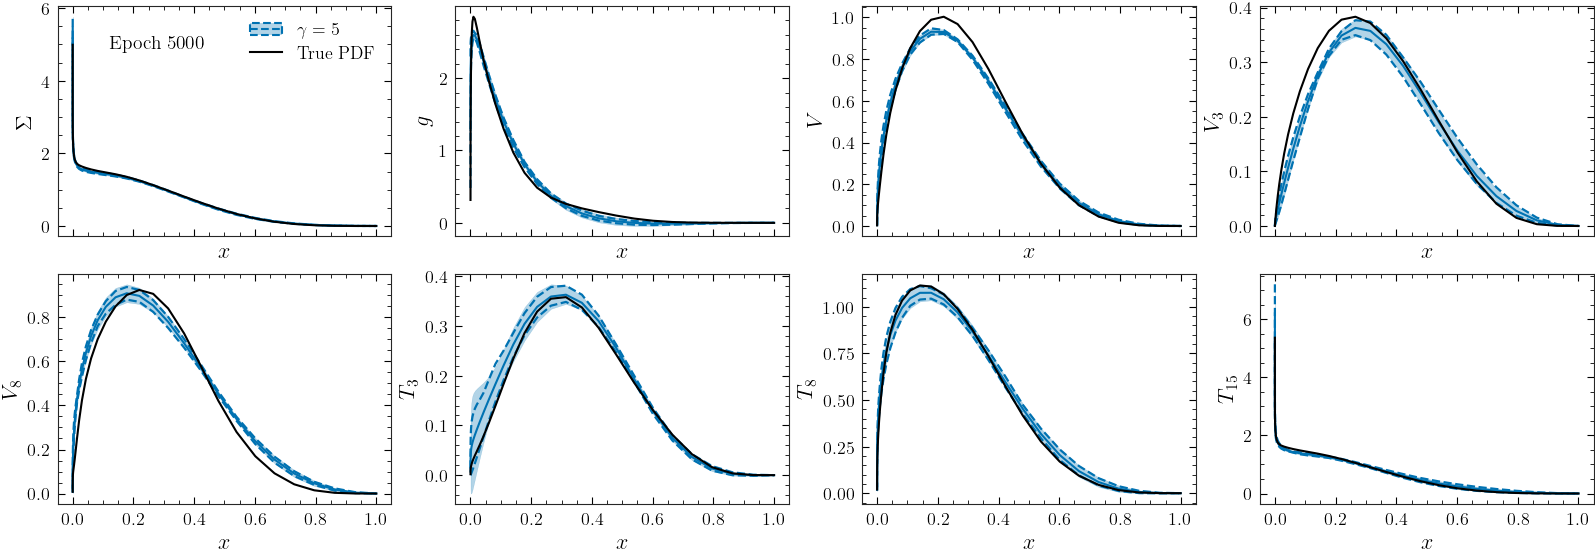

In [17]:
ncols = 4
nrows = -(-len(DEFAULT_FLAVOURS) // ncols)   # ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows),
                            sharex=True, constrained_layout=True)

_ = list(plot_grids(
  grids, 
  flavours=DEFAULT_FLAVOURS, 
  ylabels=DEFAULT_YLABELS,
  labels= [r"$\gamma = 5$", "True PDF"],
  # normalise_to=1,
  xscale="linear",
  plot_args=[
      {},
      {"linestyle": "solid", "color":"black", "no_bands": True },
  ],
  axes=axes.flatten()
))

for i, ax in enumerate(axes.flatten()):
    lg = ax.get_legend()
    if lg is not None and i != 0:
        lg.remove()
    if i == 0:
        ax.text(0.3, 0.8, "Epoch 5000", ha="center", va="bottom", transform=ax.transAxes)

plt.savefig(SAVEPATH / "pdfs_gamma_5_extended.pdf")